In [ ]:
#Data handling
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
#from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Ignore warnings
import warnings


# path handling
import os
import pathlib as path


In [ ]:
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

 # Data Understanding

In [51]:
dataSetPath = path.Path(os.getcwd()).parent.parent / "data" / "supervised_learning" / "heart_disease.csv"
print(f"Dataset path: {dataSetPath}")
df = pd.read_csv(dataSetPath)

Dataset path: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\data\supervised_learning\heart_disease.csv


In [52]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [53]:
df.shape

(10000, 21)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [55]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [56]:
for col in df.columns:
    print(col, df[col].unique())

Age [56. 69. 46. 32. 60. 25. 78. 38. 75. 36. 40. 28. 41. 70. 53. 57. 20. 39.
 19. 61. 47. 55. 77. 50. 29. 42. 66. 44. 76. 80. 59. 45. 33. 79. 64. 68.
 72. 74. 54. 24. 26. 35. 21. 31. 67. 43. 37. 52. 34. 23. 71. 51. 27. 48.
 65. 62. 58. 18. 22. 30. 49. 73. 63. nan]
Gender ['Male' 'Female' nan]
Blood Pressure [153. 146. 126. 122. 166. 152. 121. 161. 135. 144. 179. 134. 143. 150.
 133. 173. 125. 136. 137. 139. 170. 159. 158. 171. 151. 163. 128. 165.
 129. 168. 155. 142. 127. 132. 176. 141. 160. 154. 164. 138. 149. 178.
 140. 147.  nan 175. 162. 157. 174. 123. 145. 124. 148. 169. 172. 167.
 131. 120. 177. 130. 180. 156.]
Cholesterol Level [155. 286. 216. 293. 242. 257. 175. 187. 291. 252. 191. 296. 215. 290.
 255. 245. 219. 246. 268. 300. 223. 206. 259. 228. 185. 278. 152. 163.
 183. 218. 253. 178. 197. 243. 266. 287. 281. 224. 177. 270. 158. 283.
 272. 198. 240. 274. 225. 299. 298. 182. 202. 189. 167. 162. 254. 280.
 151. 284. 292. 288. 277. 176. 170. 157. 232. 204. 199. 261. 295. 179.
 1

In [57]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [58]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


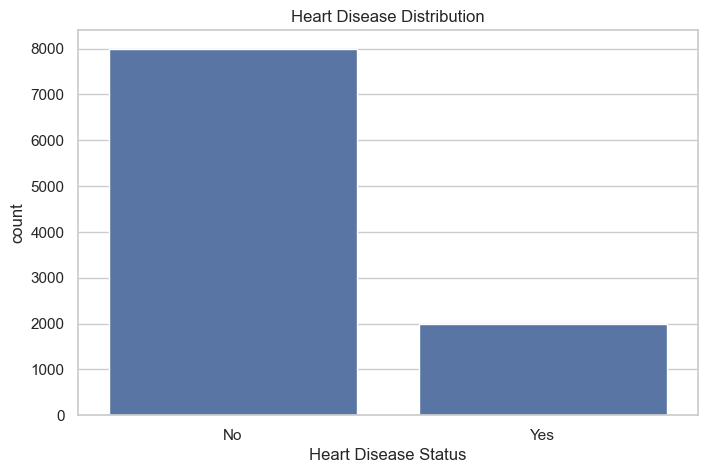

In [59]:
sns.countplot(x='Heart Disease Status', data=df)

plt.title("Heart Disease Distribution")
plt.show()

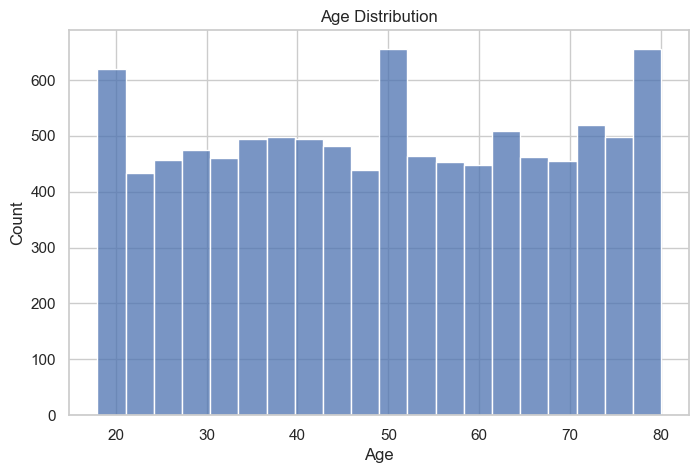

In [60]:
sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")
plt.show()

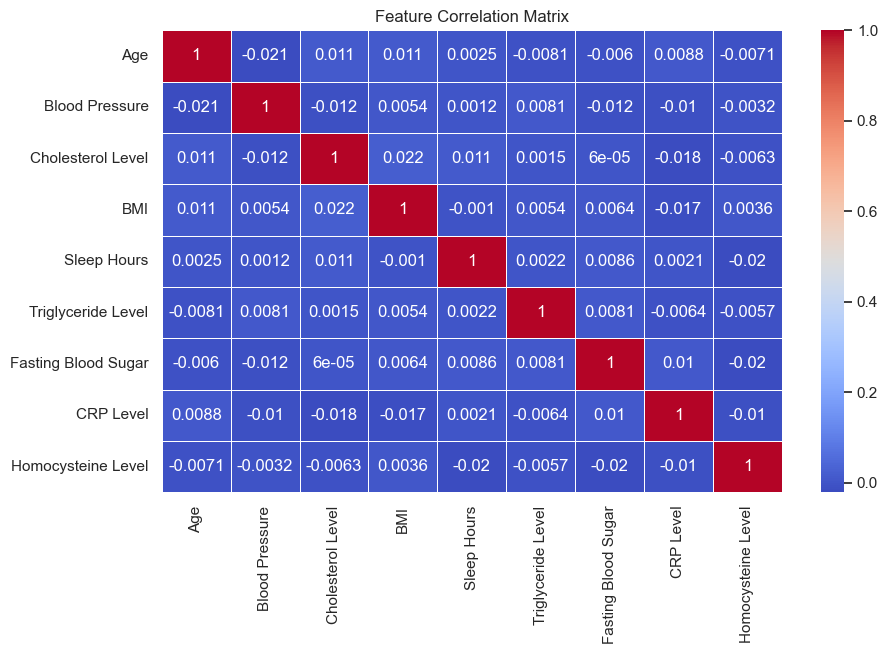

In [61]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Matrix")

plt.show()

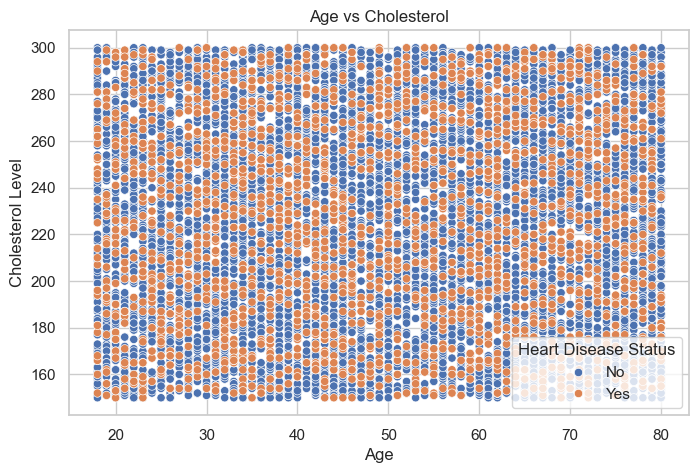

In [62]:
sns.scatterplot(x='Age', y='Cholesterol Level', hue='Heart Disease Status', data=df)
plt.title("Age vs Cholesterol")
plt.show()

# Data Preprocessing

In [63]:
print(df['Heart Disease Status'].value_counts())

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


In [64]:
df['Heart Disease Status'] = df['Heart Disease Status'].map({'No':0, 'Yes':1})

In [65]:
df['Heart Disease Status'].unique()
print(df['Heart Disease Status'].value_counts())

Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


In [66]:
# Separate features and target
X = df.drop('Heart Disease Status', axis=1)
y = df['Heart Disease Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 20)
Target shape: (10000,)


In [67]:
categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
       'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
       'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
       'Sugar Consumption'],
      dtype='object')

In [68]:
categorical_cols_all = X[categorical_cols].apply(lambda x: x.unique())

print(categorical_cols_all)

Gender                       [Male, Female, nan]
Exercise Habits         [High, Low, Medium, nan]
Smoking                           [Yes, No, nan]
Family Heart Disease              [Yes, No, nan]
Diabetes                          [No, Yes, nan]
High Blood Pressure               [Yes, No, nan]
Low HDL Cholesterol               [Yes, No, nan]
High LDL Cholesterol              [No, Yes, nan]
Alcohol Consumption     [High, Medium, Low, nan]
Stress Level            [Medium, High, Low, nan]
Sugar Consumption       [Medium, Low, High, nan]
dtype: object


In [69]:
# Define binary and ordinal columns based on characteristics of the data
binary_cols = [
    'Gender',
    'Smoking',
    'Family Heart Disease',
    'Diabetes',
    'High Blood Pressure',
    'Low HDL Cholesterol',
    'High LDL Cholesterol'
]

ordinal_cols = [
    'Exercise Habits',
    'Alcohol Consumption',
    'Stress Level',
    'Sugar Consumption'
]


In [70]:
X[numeric_df.columns] = X[numeric_df.columns].fillna(X[numeric_df.columns].median())
X[binary_cols] = X[binary_cols].fillna(X[binary_cols].mode().iloc[0])
X[ordinal_cols] = X[ordinal_cols].fillna(X[ordinal_cols].mode().iloc[0])

In [71]:
X.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
dtype: int64

In [72]:
for col in X.columns:
    print(col, X[col].unique())

Age [56. 69. 46. 32. 60. 25. 78. 38. 75. 36. 40. 28. 41. 70. 53. 57. 20. 39.
 19. 61. 47. 55. 77. 50. 29. 42. 66. 44. 76. 80. 59. 45. 33. 79. 64. 68.
 72. 74. 54. 24. 26. 35. 21. 31. 67. 43. 37. 52. 34. 23. 71. 51. 27. 48.
 65. 62. 58. 18. 22. 30. 49. 73. 63.]
Gender ['Male' 'Female']
Blood Pressure [153. 146. 126. 122. 166. 152. 121. 161. 135. 144. 179. 134. 143. 150.
 133. 173. 125. 136. 137. 139. 170. 159. 158. 171. 151. 163. 128. 165.
 129. 168. 155. 142. 127. 132. 176. 141. 160. 154. 164. 138. 149. 178.
 140. 147. 175. 162. 157. 174. 123. 145. 124. 148. 169. 172. 167. 131.
 120. 177. 130. 180. 156.]
Cholesterol Level [155. 286. 216. 293. 242. 257. 175. 187. 291. 252. 191. 296. 215. 290.
 255. 245. 219. 246. 268. 300. 223. 206. 259. 228. 185. 278. 152. 163.
 183. 218. 253. 178. 197. 243. 266. 287. 281. 224. 177. 270. 158. 283.
 272. 198. 240. 274. 225. 299. 298. 182. 202. 189. 167. 162. 254. 280.
 151. 284. 292. 288. 277. 176. 170. 157. 232. 204. 199. 261. 295. 179.
 188. 265. 289.

In [73]:
# Binary encoding (Yes/No, Male/Female)
binary_map = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

for col in binary_cols:
    X[col] = X[col].map(binary_map)

# Ordinal encoding (Low < Medium < High)
ordinal_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

for col in ordinal_cols:
    X[col] = X[col].map(ordinal_map)
X.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,1,153.0,155.0,2,1,1,0,24.991591,1,1,0,2,1,7.633228,1,342.0,120.0,12.969246,12.387250
1,69.0,0,146.0,286.0,2,0,1,1,25.221799,0,1,0,1,2,8.744034,1,133.0,157.0,9.355389,19.298875
2,46.0,1,126.0,216.0,0,0,0,0,29.855447,0,1,1,0,0,4.440440,0,393.0,92.0,12.709873,11.230926
3,32.0,0,122.0,293.0,2,1,1,0,24.130477,1,0,1,0,2,5.249405,2,293.0,94.0,12.509046,5.961958
4,60.0,1,166.0,242.0,0,1,1,1,20.486289,1,0,0,0,2,7.030971,2,263.0,154.0,10.381259,8.153887


In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,0.369061,0.99561,0.184661,-1.618712,1.209336,0.970825,1.005013,-0.990446,-0.648537,0.990446,0.995012,-0.987676,1.435436,0.006036,0.366591,0.010955,1.049660,-0.006024,1.268241,-0.015959
1,1.084657,-1.00441,-0.214077,1.392213,1.209336,-1.030051,1.005013,1.009647,-0.611996,-1.009647,0.995012,-0.987676,0.008845,1.237813,1.001005,0.010955,-1.354031,1.564643,0.434477,1.584367
2,-0.181398,0.99561,-1.353328,-0.216679,-1.240200,-1.030051,-0.995012,-0.990446,0.123523,-1.009647,0.995012,1.012478,-1.417746,-1.225742,-1.456907,-1.206279,1.636206,-1.194636,1.208400,-0.283696
3,-0.952040,-1.00441,-1.581178,1.553102,1.209336,0.970825,1.005013,-0.990446,-0.785226,0.990446,-1.005013,1.012478,-1.417746,1.237813,-0.994883,1.228189,0.486115,-1.109735,1.162067,-1.503680
4,0.589244,0.99561,0.925175,0.380910,-1.240200,0.970825,1.005013,1.009647,-1.363683,0.990446,-1.005013,-0.987676,-1.417746,1.237813,0.022624,1.228189,0.141087,1.437292,0.671158,-0.996158


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 20)
Test size: (2000, 20)


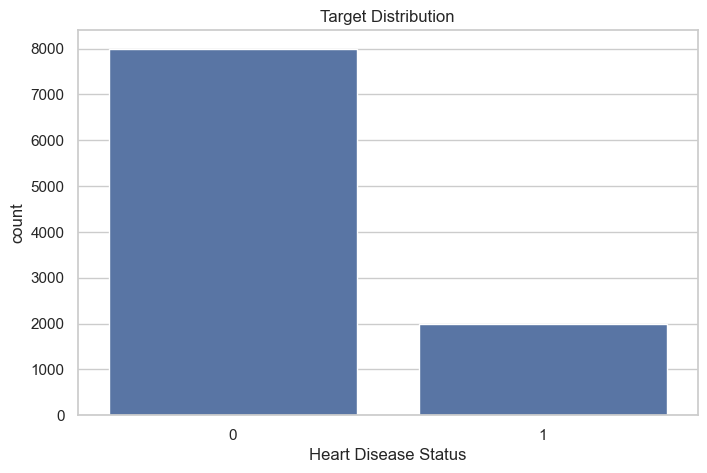

In [77]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

# Supervised Learning

In [78]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42)
    
}

results = {}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8065
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000


Random Forest
Accuracy: 0.8065
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000


Decision Tree
Accuracy: 0.6615
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1613
           1       0.18      0.21      0.20       387

    accuracy                           0.66      2000
   macro avg       0.49   

In [79]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.8065
1,Random Forest,0.8065
4,Support Vector Machine,0.8065
3,K-Nearest Neighbors,0.7735
2,Decision Tree,0.6615


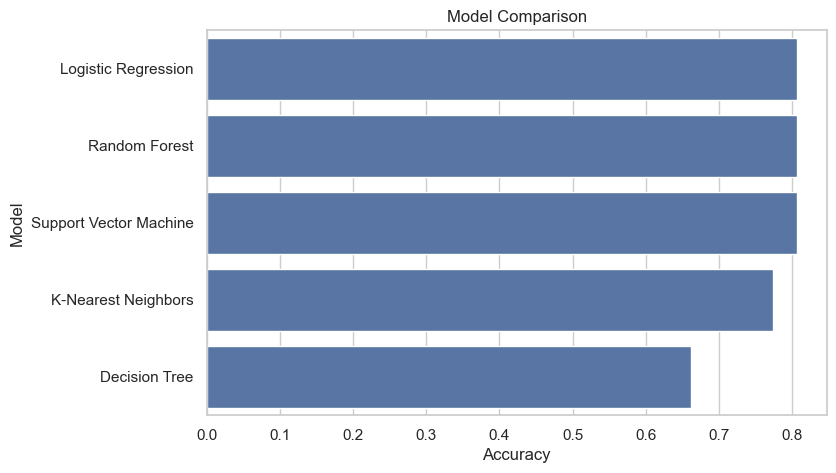

In [80]:
sns.barplot(x='Accuracy', y='Model', data=results_df)

plt.title("Model Comparison")
plt.show()

In [81]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Logistic Regression
Best Accuracy: 0.8065


In [82]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'kernel': 'linear'}


In [83]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
8,BMI,0.100374
18,CRP Level,0.097809
19,Homocysteine Level,0.095828
14,Sleep Hours,0.095600
16,Triglyceride Level,0.091341
3,Cholesterol Level,0.085612
17,Fasting Blood Sugar,0.083175
0,Age,0.079500
2,Blood Pressure,0.078652
4,Exercise Habits,0.024312


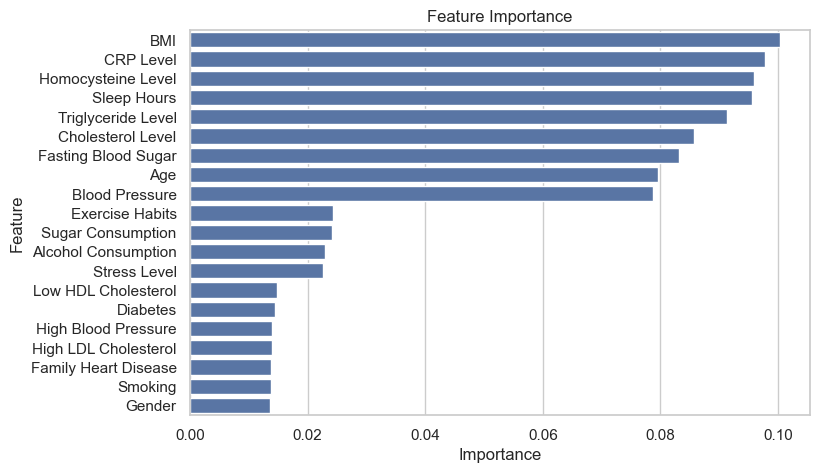

In [84]:
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance")
plt.show()

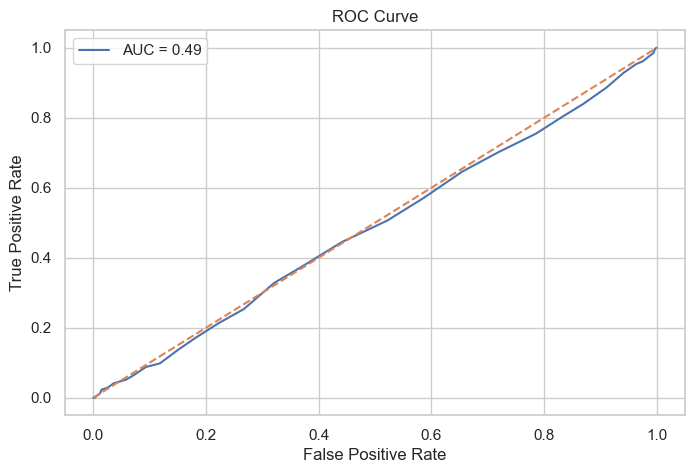

In [85]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()